In [20]:
from google.colab import files
uploaded = files.upload()

Saving flight_data_2024_sample.csv to flight_data_2024_sample (1).csv


In [72]:
import pandas as pd

df = pd.read_csv("flight_data_2024_sample.csv")
print(df.head())

   year  month  day_of_month  day_of_week     fl_date op_unique_carrier  \
0  2024      4            18            4  2024-04-18                MQ   
1  2024      1             1            1  2024-01-01                AA   
2  2024     12            12            4  2024-12-12                9E   
3  2024      4             8            1  2024-04-08                WN   
4  2024      2            16            5  2024-02-16                WN   

   op_carrier_fl_num origin       origin_city_name origin_state_nm  ...  \
0             3535.0    DFW  Dallas/Fort Worth, TX           Texas  ...   
1              148.0    CLT          Charlotte, NC  North Carolina  ...   
2             5440.0    CHA        Chattanooga, TN       Tennessee  ...   
3             1971.0    OMA              Omaha, NE        Nebraska  ...   
4              862.0    BWI          Baltimore, MD        Maryland  ...   

  diverted crs_elapsed_time actual_elapsed_time  air_time  distance  \
0        0            151.0

In [40]:
!pip install xgboost imbalanced-learn shap

In [73]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("plots", exist_ok=True)
os.makedirs("model_artifacts", exist_ok=True)

print("All libraries imported successfully!")

All libraries imported successfully!


In [75]:
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), low_memory=False)

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

print(f"Data Loaded Successfully!")
print(f"   Shape     : {df.shape}")
print(f"   Columns   : {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Data Loaded Successfully!
   Shape     : (10000, 35)
   Columns   : ['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

First 5 rows:


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [77]:
# CELL 4 — Data Cleaning

print("=" * 55)
print("  STEP 1: DATA CLEANING")
print("=" * 55)
missing  = df.isnull().sum()
miss_pct = (missing / len(df) * 100).round(2)
miss_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': miss_pct})
miss_df  = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("\n Missing Values Report:")
print(miss_df.head(20).to_string())

# 4.2 Drop fully empty rows
df.dropna(how='all', inplace=True)

# 4.3 Delay cause columns — fill NaN with 0
delay_cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay',
                    'security_delay', 'late_aircraft_delay']
for col in delay_cause_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 4.4 Drop columns missing more than 60%
high_miss = [c for c in df.columns
             if df[c].isnull().mean() > 0.60
             and c not in delay_cause_cols]
if high_miss:
    print(f"\nDropping high-missing columns (>60%): {high_miss}")
    df.drop(columns=high_miss, inplace=True)

# 4.5 Fill remaining numeric cols with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# 4.6 Fill remaining categorical cols with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 4.7 Drop duplicate rows
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\n Removed {before - df.shape[0]} duplicate rows")

print(f"\n Cleaned Shape: {df.shape}")
df.head()

  STEP 1: DATA CLEANING

 Missing Values Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Removed 0 duplicate rows

 Cleaned Shape: (10000, 34)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


In [78]:
# CELL 5 — Feature Engineering

print("=" * 55)
print("  STEP 2: FEATURE ENGINEERING")
print("=" * 55)

# 5.1 Target variable — flight delayed > 15 min
if 'arr_delay' in df.columns:
    df['arr_delay'] = pd.to_numeric(df['arr_delay'], errors='coerce').fillna(0)
    df['Is_Delayed'] = (df['arr_delay'] > 15).astype(int)
    delay_col = 'arr_delay'
elif 'dep_delay' in df.columns:
    df['dep_delay'] = pd.to_numeric(df['dep_delay'], errors='coerce').fillna(0)
    df['Is_Delayed'] = (df['dep_delay'] > 15).astype(int)
    delay_col = 'dep_delay'
else:
    raise ValueError("No arr_delay or dep_delay column found!")

print(f"Target: Is_Delayed  |  Delay Rate: {df['Is_Delayed'].mean()*100:.1f}%")
print(f"   On Time : {(df['Is_Delayed']==0).sum():,}")
print(f"   Delayed : {(df['Is_Delayed']==1).sum():,}")

# 5.2 Parse departure hour from crs_dep_time (format: HHMM e.g. 1530 = 15:30)
if 'crs_dep_time' in df.columns:
    df['crs_dep_time'] = pd.to_numeric(df['crs_dep_time'], errors='coerce').fillna(0)
    df['dep_hour']   = (df['crs_dep_time'] // 100).astype(int).clip(0, 23)
    df['dep_minute'] = (df['crs_dep_time'] % 100).astype(int).clip(0, 59)
else:
    df['dep_hour']   = 12
    df['dep_minute'] = 0

# 5.3 Time-of-day bins
#   0=Red-Eye(0-5)  1=Early Morning(6-8)  2=Morning(9-11)
#   3=Afternoon(12-16)  4=Evening(17-20)  5=Night(21-23)
bins   = [-1, 5, 8, 11, 16, 20, 23]
labels = [0,  1,  2,  3,   4,   5]
df['dep_time_bin'] = pd.cut(df['dep_hour'], bins=bins, labels=labels).astype(int)

# 5.4 Peak hour flag (morning rush + evening rush)
df['peak_hour'] = ((df['dep_hour'].between(6, 9)) |
                   (df['dep_hour'].between(17, 21))).astype(int)

# 5.5 Red-eye flag
df['red_eye'] = ((df['dep_hour'] <= 5) | (df['dep_hour'] >= 22)).astype(int)

# 5.6 Weekend flag (6=Sat, 7=Sun or 0=Sun depending on source)
df['weekend'] = df['day_of_week'].apply(lambda x: 1 if x in [6, 7, 0] else 0)

# 5.7 Monday / Friday flags (most delay-prone days)
df['is_monday'] = (df['day_of_week'] == 1).astype(int)
df['is_friday'] = (df['day_of_week'] == 5).astype(int)

# 5.8 Season  (1=Winter  2=Spring  3=Summer  4=Fall)
season_map = {12:1, 1:1, 2:1,
               3:2, 4:2, 5:2,
               6:3, 7:3, 8:3,
               9:4, 10:4, 11:4}
df['season'] = df['month'].map(season_map).fillna(1).astype(int)

# 5.9 Quarter
df['quarter'] = ((df['month'] - 1) // 3 + 1).astype(int)

# 5.10 Distance bin  (0=Short <500mi  1=Medium  2=Long  3=Ultra >1500mi)
if 'distance' in df.columns:
    df['distance'] = pd.to_numeric(df['distance'], errors='coerce').fillna(800)
    df['distance_bin'] = pd.cut(df['distance'],
                                bins=[0, 500, 1000, 1500, 99999],
                                labels=[0, 1, 2, 3]).astype(int)

# 5.11 Scheduled elapsed time
if 'crs_elapsed_time' in df.columns:
    df['crs_elapsed_time'] = pd.to_numeric(df['crs_elapsed_time'], errors='coerce').fillna(120)

# 5.12 Route column (for analysis & rate calculation)
if 'origin' in df.columns and 'dest' in df.columns:
    df['route'] = df['origin'].astype(str) + '-' + df['dest'].astype(str)

# 5.13 Historical delay rates (Target Encoding)
carrier_col = 'op_unique_carrier' if 'op_unique_carrier' in df.columns else 'op_carrier'

if carrier_col in df.columns:
    df['airline_delay_rate'] = df[carrier_col].map(
        df.groupby(carrier_col)['Is_Delayed'].mean())

if 'origin' in df.columns:
    df['origin_delay_rate'] = df['origin'].map(
        df.groupby('origin')['Is_Delayed'].mean())

if 'dest' in df.columns:
    df['dest_delay_rate'] = df['dest'].map(
        df.groupby('dest')['Is_Delayed'].mean())

if 'route' in df.columns:
    df['route_delay_rate'] = df['route'].map(
        df.groupby('route')['Is_Delayed'].mean())

# 5.14 Flight number frequency (busy route proxy)
if 'op_carrier_fl_num' in df.columns:
    fl_freq = df['op_carrier_fl_num'].value_counts()
    df['fl_num_freq'] = df['op_carrier_fl_num'].map(fl_freq).fillna(1)

print(f"\nFeature engineering done  |  Shape: {df.shape}")
print(f"\nNew columns added:")
new_cols = ['dep_hour','dep_minute','dep_time_bin','peak_hour','red_eye',
            'weekend','is_monday','is_friday','season','quarter',
            'distance_bin','airline_delay_rate','origin_delay_rate',
            'dest_delay_rate','route_delay_rate','fl_num_freq','Is_Delayed']
for c in new_cols:
    if c in df.columns:
        print(f"   ✓ {c}")

  STEP 2: FEATURE ENGINEERING
Target: Is_Delayed  |  Delay Rate: 20.4%
   On Time : 7,960
   Delayed : 2,040

Feature engineering done  |  Shape: (10000, 52)

New columns added:
   ✓ dep_hour
   ✓ dep_minute
   ✓ dep_time_bin
   ✓ peak_hour
   ✓ red_eye
   ✓ weekend
   ✓ is_monday
   ✓ is_friday
   ✓ season
   ✓ quarter
   ✓ distance_bin
   ✓ airline_delay_rate
   ✓ origin_delay_rate
   ✓ dest_delay_rate
   ✓ route_delay_rate
   ✓ fl_num_freq
   ✓ Is_Delayed


In [79]:
# CELL 6 — Outlier Handling (Winsorization)

print("=" * 55)
print("  STEP 3: OUTLIER HANDLING")
print("=" * 55)

cols_to_winsorize = [delay_col, 'crs_elapsed_time', 'distance']

for col in cols_to_winsorize:
    if col not in df.columns:
        continue
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(low, high)
    after_min, after_max = df[col].min(), df[col].max()
    print(f"  {col:22s}  Before: [{before_min:.1f}, {before_max:.1f}]"
          f"  →  After: [{after_min:.1f}, {after_max:.1f}]")

print("\n Outliers winsorized!")

  STEP 3: OUTLIER HANDLING
  arr_delay               Before: [-78.0, 2014.0]  →  After: [-51.0, 45.0]
  crs_elapsed_time        Before: [23.0, 685.0]  →  After: [23.0, 308.0]
  distance                Before: [31.0, 5095.0]  →  After: [31.0, 2074.0]

 Outliers winsorized!


  STEP 4: EXPLORATORY DATA ANALYSIS


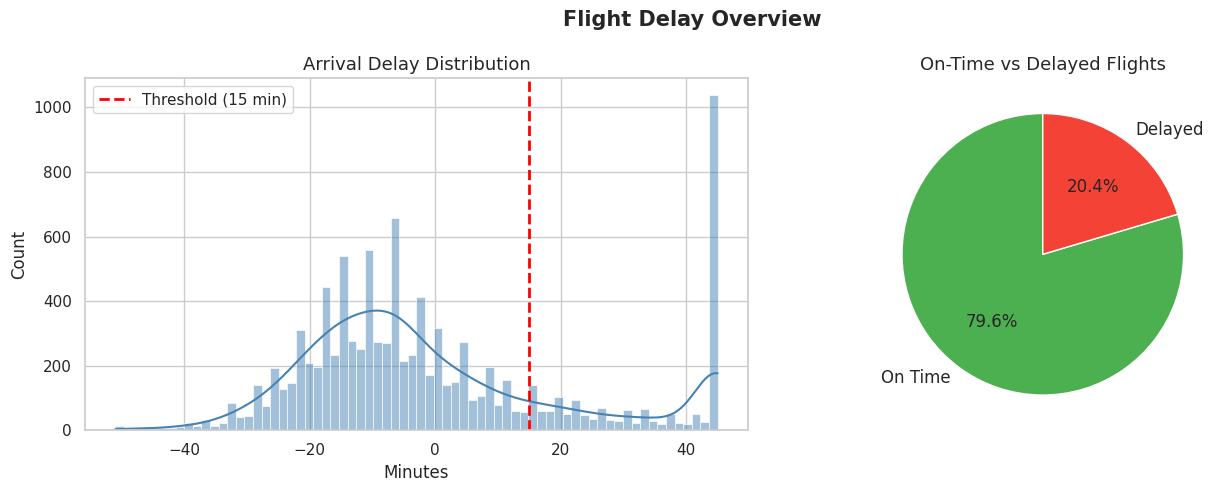

Plot saved: plots/01_delay_overview.png


In [80]:
# CELL 7 — EDA: Delay Distribution & Class Balance

print("=" * 55)
print("  STEP 4: EXPLORATORY DATA ANALYSIS")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay distribution
sns.histplot(df[delay_col].clip(-60, 200), bins=70, kde=True,
             ax=axes[0], color='steelblue')
axes[0].axvline(15, color='red', linestyle='--', linewidth=2,
                label='Threshold (15 min)')
axes[0].set_title("Arrival Delay Distribution", fontsize=13)
axes[0].set_xlabel("Minutes")
axes[0].legend()

# Pie chart
counts = df['Is_Delayed'].value_counts()
axes[1].pie(counts, labels=['On Time', 'Delayed'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title("On-Time vs Delayed Flights", fontsize=13)

plt.suptitle("Flight Delay Overview", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/01_delay_overview.png", dpi=150)
plt.show()
print("Plot saved: plots/01_delay_overview.png")

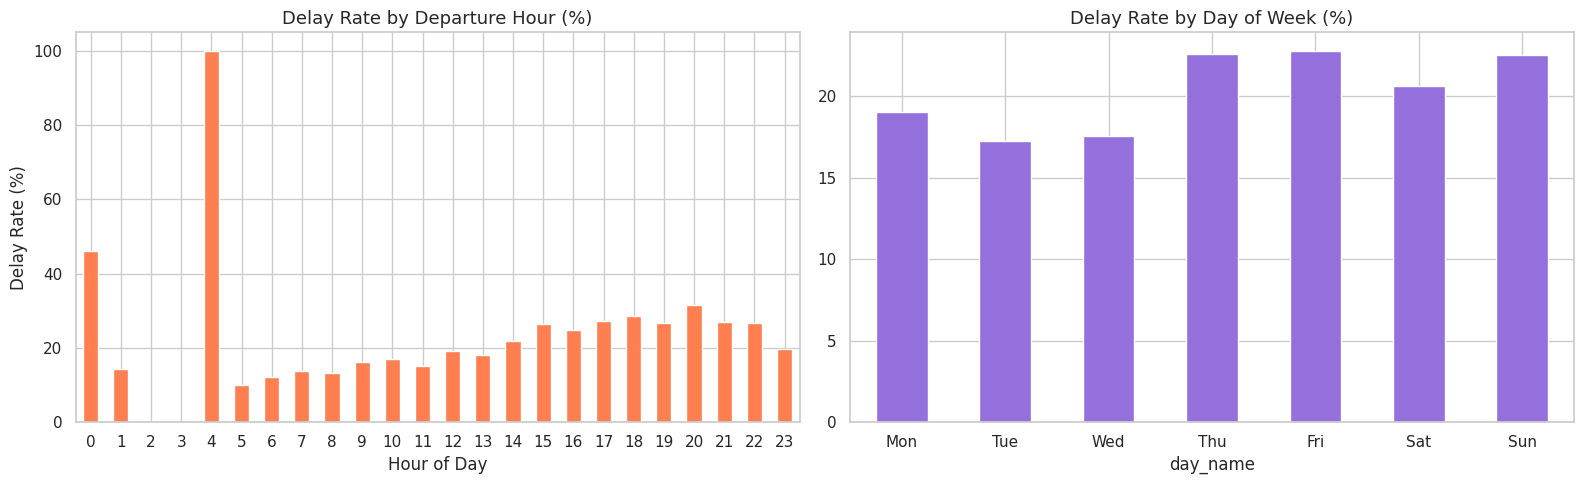

 Plot saved: plots/02_delay_by_hour_day.png


In [81]:
# CELL 8 — EDA: Delay Rate by Hour and Day of Week

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By hour
if 'dep_hour' in df.columns:
    hr_delay = df.groupby('dep_hour')['Is_Delayed'].mean() * 100
    hr_delay.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
    axes[0].set_title("Delay Rate by Departure Hour (%)", fontsize=13)
    axes[0].set_xlabel("Hour of Day")
    axes[0].set_ylabel("Delay Rate (%)")
    axes[0].tick_params(axis='x', rotation=0)

# By day of week
if 'day_of_week' in df.columns:
    day_map = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun', 0:'Sun'}
    df['day_name'] = df['day_of_week'].map(day_map)
    order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    day_delay = df.groupby('day_name')['Is_Delayed'].mean().reindex(order) * 100
    day_delay.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
    axes[1].set_title("Delay Rate by Day of Week (%)", fontsize=13)
    axes[1].tick_params(axis='x', rotation=0)
    df.drop(columns=['day_name'], inplace=True, errors='ignore')

plt.tight_layout()
plt.savefig("plots/02_delay_by_hour_day.png", dpi=150)
plt.show()
print(" Plot saved: plots/02_delay_by_hour_day.png")

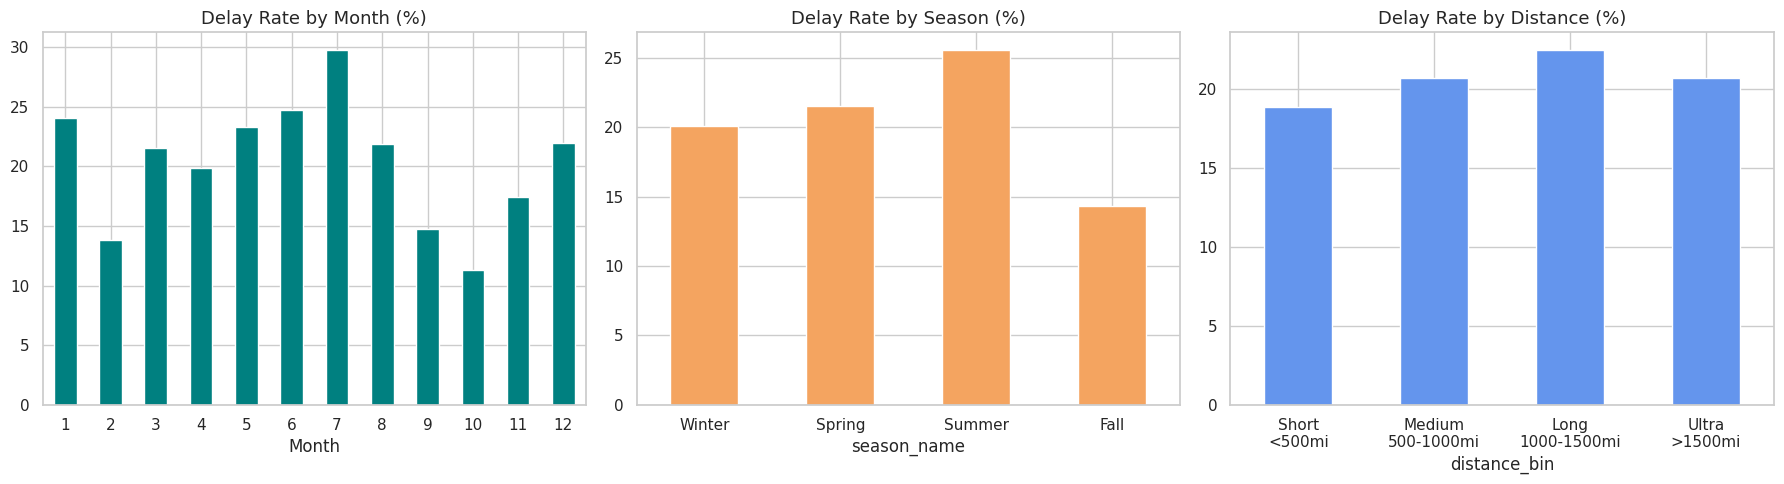

Plot saved: plots/03_delay_by_month_season_distance.png


In [82]:
# CELL 9 — EDA: Delay by Month, Season, Distance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By month
if 'month' in df.columns:
    month_delay = df.groupby('month')['Is_Delayed'].mean() * 100
    month_delay.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
    axes[0].set_title("Delay Rate by Month (%)", fontsize=13)
    axes[0].set_xlabel("Month")
    axes[0].tick_params(axis='x', rotation=0)

# By season
if 'season' in df.columns:
    s_map = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'}
    df['season_name'] = df['season'].map(s_map)
    season_delay = df.groupby('season_name')['Is_Delayed'].mean().reindex(
        ['Winter','Spring','Summer','Fall']) * 100
    season_delay.plot(kind='bar', ax=axes[1], color='sandybrown', edgecolor='white')
    axes[1].set_title("Delay Rate by Season (%)", fontsize=13)
    axes[1].tick_params(axis='x', rotation=0)
    df.drop(columns=['season_name'], inplace=True, errors='ignore')

# By distance bin
if 'distance_bin' in df.columns:
    dlabels = {0:'Short\n<500mi', 1:'Medium\n500-1000mi',
               2:'Long\n1000-1500mi', 3:'Ultra\n>1500mi'}
    dist_delay = df.groupby('distance_bin')['Is_Delayed'].mean() * 100
    dist_delay.index = dist_delay.index.map(dlabels)
    dist_delay.plot(kind='bar', ax=axes[2], color='cornflowerblue', edgecolor='white')
    axes[2].set_title("Delay Rate by Distance (%)", fontsize=13)
    axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("plots/03_delay_by_month_season_distance.png", dpi=150)
plt.show()
print("Plot saved: plots/03_delay_by_month_season_distance.png")

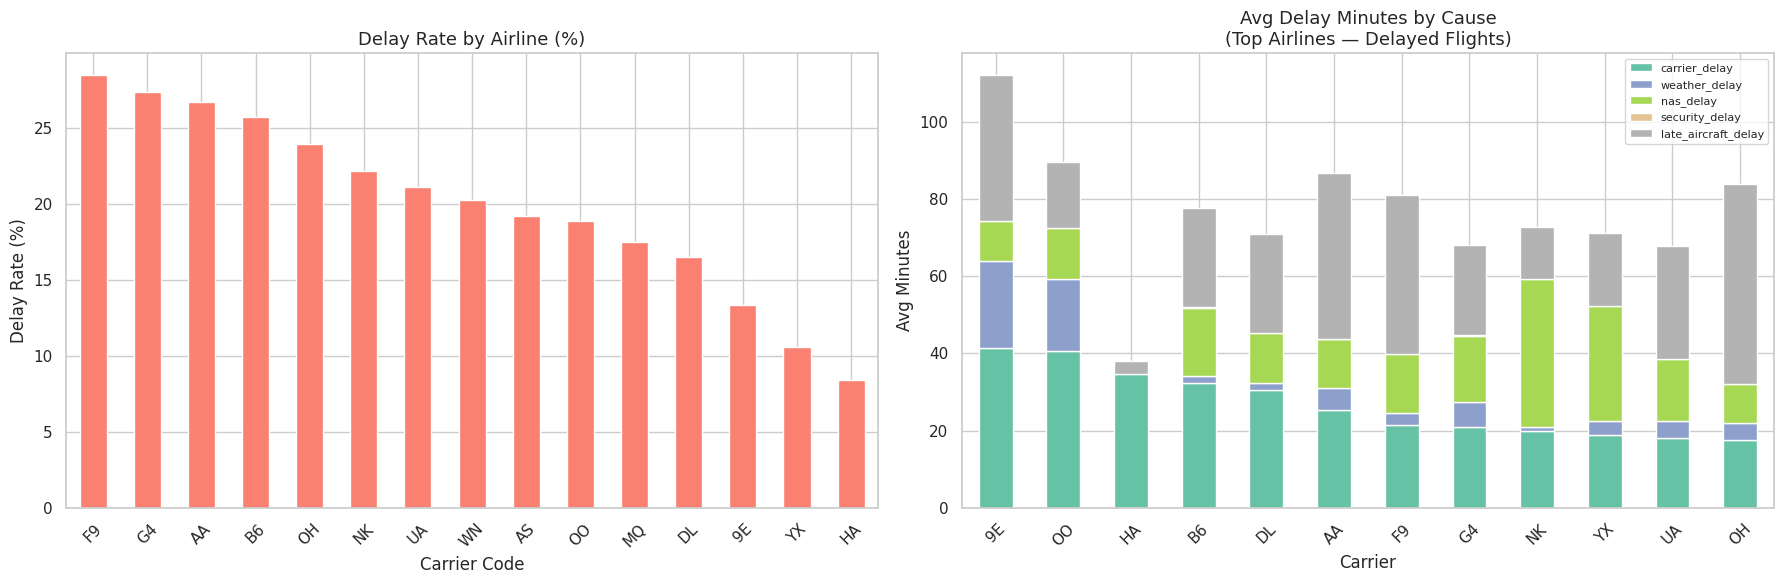

 Plot saved: plots/04_airline_analysis.png


In [83]:
# CELL 10 — EDA: Delay Rate by Airline + Delay Cause Breakdown

carrier_col = 'op_unique_carrier' if 'op_unique_carrier' in df.columns else 'op_carrier'
delay_cause_cols = [c for c in ['carrier_delay','weather_delay','nas_delay',
                                 'security_delay','late_aircraft_delay']
                    if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Delay rate per airline
if carrier_col in df.columns:
    airline_delay = (df.groupby(carrier_col)['Is_Delayed']
                       .mean()
                       .sort_values(ascending=False) * 100)
    airline_delay.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
    axes[0].set_title("Delay Rate by Airline (%)", fontsize=13)
    axes[0].set_xlabel("Carrier Code")
    axes[0].set_ylabel("Delay Rate (%)")
    axes[0].tick_params(axis='x', rotation=45)

# Delay cause breakdown (delayed flights only)
if delay_cause_cols and carrier_col in df.columns:
    cause_data = (df[df['Is_Delayed'] == 1]
                  .groupby(carrier_col)[delay_cause_cols]
                  .mean()
                  .sort_values('carrier_delay', ascending=False)
                  .head(12))
    cause_data.plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='Set2', edgecolor='white')
    axes[1].set_title("Avg Delay Minutes by Cause\n(Top Airlines — Delayed Flights)", fontsize=13)
    axes[1].set_xlabel("Carrier")
    axes[1].set_ylabel("Avg Minutes")
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("plots/04_airline_analysis.png", dpi=150)
plt.show()
print(" Plot saved: plots/04_airline_analysis.png")

  ROUTE RISK ANALYSIS

Top 15 Most Delay-Prone Routes:
Empty DataFrame
Columns: [route, Total_Flights, Delayed_Flights, Delay_Rate, Avg_Delay_Min]
Index: []


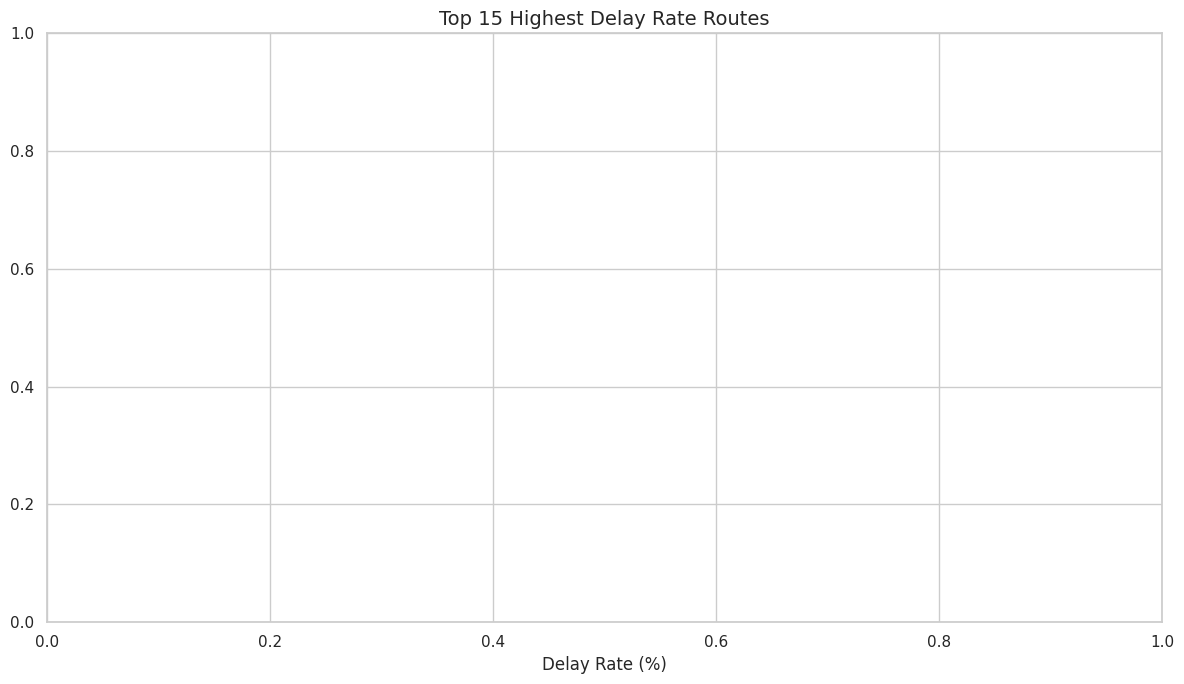


Plot saved: plots/05_route_risk.png


In [84]:
# CELL 11 — Route Risk Analysis (Top Delay-Prone Routes)

print("=" * 55)
print("  ROUTE RISK ANALYSIS")
print("=" * 55)

if 'route' in df.columns:
    route_stats = (df.groupby('route')
                     .agg(
                         Total_Flights = ('Is_Delayed', 'count'),
                         Delayed_Flights= ('Is_Delayed', 'sum'),
                         Delay_Rate    = ('Is_Delayed', 'mean'),
                         Avg_Delay_Min = (delay_col, 'mean')
                     )
                     .reset_index())
    route_stats = (route_stats[route_stats['Total_Flights'] >= 30]
                              .sort_values('Delay_Rate', ascending=False))

    print("\nTop 15 Most Delay-Prone Routes:")
    print(route_stats.head(15).to_string(index=False))

    plt.figure(figsize=(12, 7))
    top_routes = route_stats.head(15).copy()
    top_routes['Delay_Rate_%'] = top_routes['Delay_Rate'] * 100
    sns.barplot(data=top_routes, x='Delay_Rate_%', y='route', palette='Reds_r')
    plt.title("Top 15 Highest Delay Rate Routes", fontsize=14)
    plt.xlabel("Delay Rate (%)")
    plt.tight_layout()
    plt.savefig("plots/05_route_risk.png", dpi=150)
    plt.show()
    print("\nPlot saved: plots/05_route_risk.png")
else:
    print("Route column not found — skipping.")

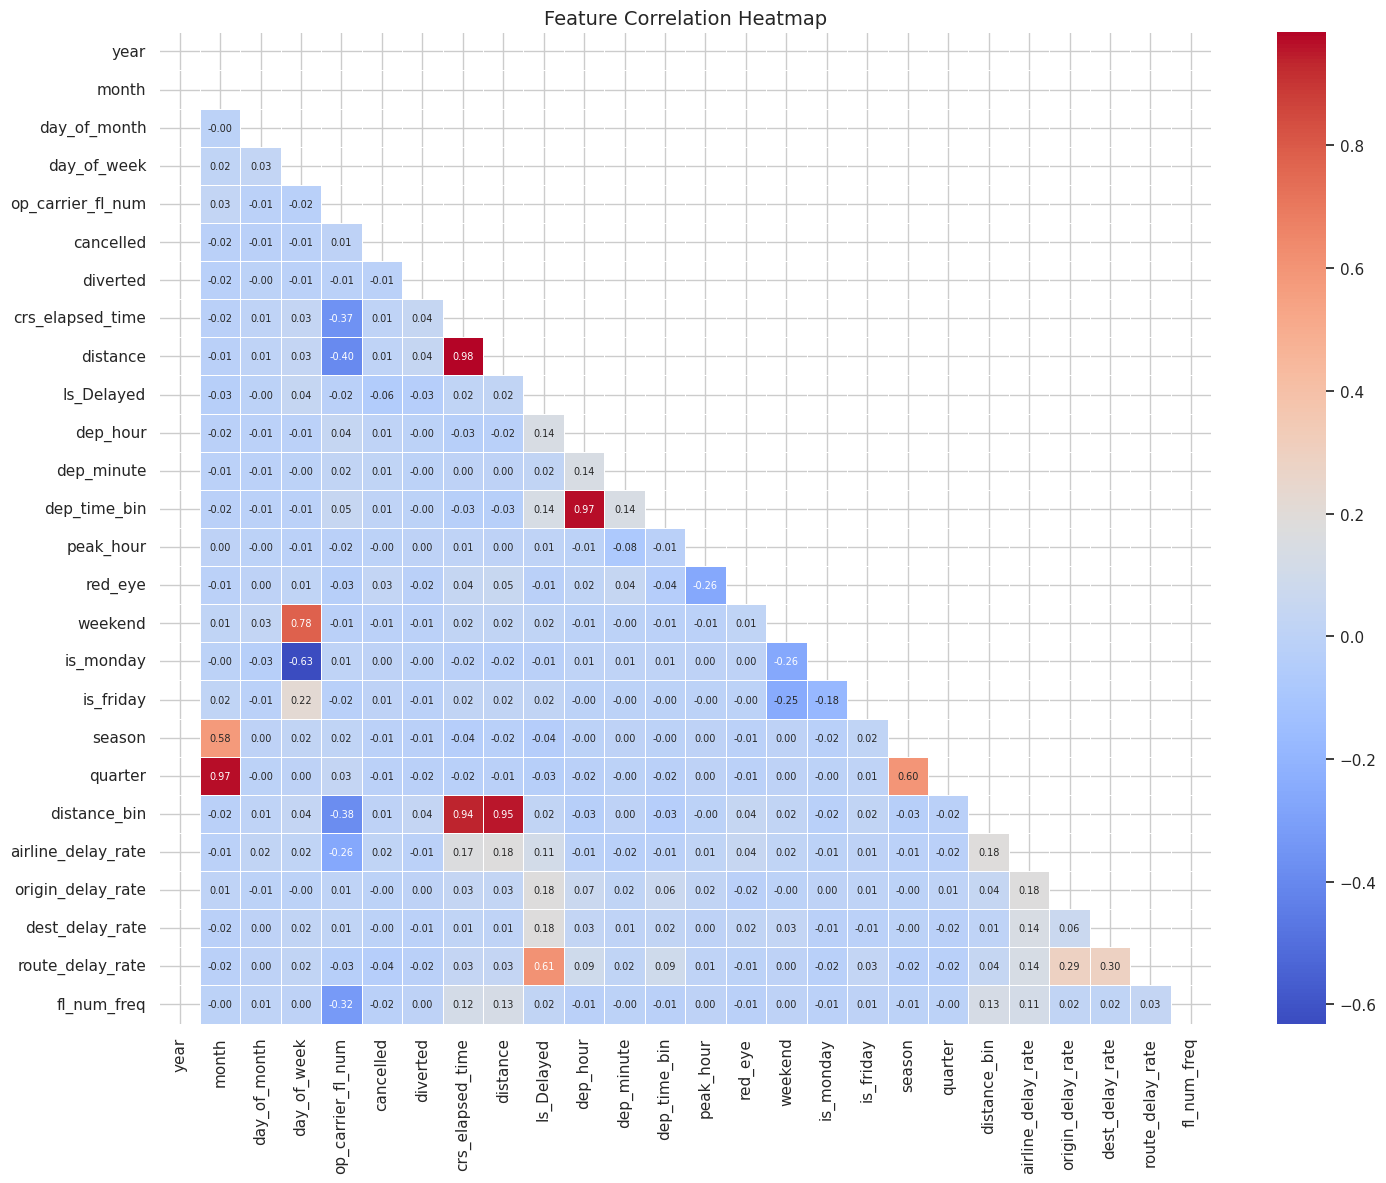

Plot saved: plots/06_correlation_heatmap.png


In [85]:
# CELL 12 — Correlation Heatmap

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove raw delay/time columns that would leak into target
exclude = [delay_col, 'arr_delay', 'dep_delay',
           'actual_elapsed_time', 'air_time',
           'carrier_delay','weather_delay','nas_delay',
           'security_delay','late_aircraft_delay',
           'crs_dep_time','crs_arr_time','dep_time','arr_time',
           'taxi_out','taxi_in','wheels_off','wheels_on']
plot_cols = [c for c in numeric_cols if c not in exclude]

plt.figure(figsize=(15, 12))
corr = df[plot_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4,
            annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("plots/06_correlation_heatmap.png", dpi=150)
plt.show()
print("Plot saved: plots/06_correlation_heatmap.png")

In [86]:
# CELL 13 — Label Encoding for Categorical Features

print("=" * 55)
print("  STEP 5: ENCODING")
print("=" * 55)

encoders = {}
carrier_col = 'op_unique_carrier' if 'op_unique_carrier' in df.columns else 'op_carrier'

encode_map = []
if carrier_col in df.columns:
    encode_map.append((carrier_col, 'airline_encoded'))
if 'origin' in df.columns:
    encode_map.append(('origin', 'origin_encoded'))
if 'dest' in df.columns:
    encode_map.append(('dest', 'dest_encoded'))

for src, dst in encode_map:
    le = LabelEncoder()
    df[dst] = le.fit_transform(df[src].astype(str))
    encoders[dst] = le
    print(f"  {src:25s} → {dst}  ({le.classes_.shape[0]} unique values)")

# Drop original text columns
df.drop(columns=[src for src, _ in encode_map], inplace=True, errors='ignore')

print(f"\n  Encoders stored: {list(encoders.keys())}")
print(f"  Shape after encoding: {df.shape}")

  STEP 5: ENCODING
  op_unique_carrier         → airline_encoded  (15 unique values)
  origin                    → origin_encoded  (284 unique values)
  dest                      → dest_encoded  (287 unique values)

  Encoders stored: ['airline_encoded', 'origin_encoded', 'dest_encoded']
  Shape after encoding: (10000, 52)


In [87]:
# CELL 14 — Feature Selection + Train/Test Split + SMOTE

print("=" * 55)
print("  STEP 6: TRAIN / TEST SPLIT + SMOTE")
print("=" * 55)

# Define feature columns
ALL_FEATURES = [
    'airline_encoded', 'origin_encoded', 'dest_encoded',
    'dep_hour', 'dep_minute', 'dep_time_bin',
    'day_of_week', 'day_of_month', 'month', 'quarter', 'season',
    'peak_hour', 'red_eye', 'weekend', 'is_monday', 'is_friday',
    'distance', 'distance_bin', 'crs_elapsed_time',
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay',
    'airline_delay_rate', 'origin_delay_rate',
    'dest_delay_rate', 'route_delay_rate',
    'fl_num_freq',
]

# Only keep columns that exist in df
FEATURE_COLS = [f for f in ALL_FEATURES if f in df.columns]

print(f"\n  Using {len(FEATURE_COLS)} features:")
for f in FEATURE_COLS:
    print(f"    ✓ {f}")

X = df[FEATURE_COLS]
y = df['Is_Delayed']

# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n  Train size : {X_train.shape}")
print(f"  Test size  : {X_test.shape}")
print(f"  Class dist (train): {y_train.value_counts().to_dict()}")

# SMOTE — balance classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
counts = dict(zip(*np.unique(y_train_res, return_counts=True)))
print(f"\n  After SMOTE : {counts}")

# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),           columns=FEATURE_COLS)

print("\n Data ready for training!")

  STEP 6: TRAIN / TEST SPLIT + SMOTE

  Using 29 features:
    ✓ airline_encoded
    ✓ origin_encoded
    ✓ dest_encoded
    ✓ dep_hour
    ✓ dep_minute
    ✓ dep_time_bin
    ✓ day_of_week
    ✓ day_of_month
    ✓ month
    ✓ quarter
    ✓ season
    ✓ peak_hour
    ✓ red_eye
    ✓ weekend
    ✓ is_monday
    ✓ is_friday
    ✓ distance
    ✓ distance_bin
    ✓ crs_elapsed_time
    ✓ carrier_delay
    ✓ weather_delay
    ✓ nas_delay
    ✓ security_delay
    ✓ late_aircraft_delay
    ✓ airline_delay_rate
    ✓ origin_delay_rate
    ✓ dest_delay_rate
    ✓ route_delay_rate
    ✓ fl_num_freq

  Train size : (8000, 29)
  Test size  : (2000, 29)
  Class dist (train): {0: 6368, 1: 1632}

  After SMOTE : {np.int64(0): np.int64(6368), np.int64(1): np.int64(6368)}

 Data ready for training!


In [88]:
# CELL 15 — Train All Models with Cross-Validation

print("=" * 55)
print("  STEP 7: MODEL TRAINING")
print("=" * 55)

cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Define models ──────────────────────────────
models_dict = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_leaf=5, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=5,
        learning_rate=0.1, subsample=0.8,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
}

# ── Train + CV ─────────────────────────────────
trained_models = {}

for name, model in models_dict.items():
    print(f"\n  Training: {name}")
    cv_scores = cross_val_score(model, X_train_scaled, y_train_res,
                                cv=cv_split, scoring='roc_auc', n_jobs=-1)
    print(f"    5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    model.fit(X_train_scaled, y_train_res)
    trained_models[name] = model
    print(f"    Trained!")

# ── Voting Ensemble ────────────────────────────
print(f"\n   Training: Voting Ensemble (RF + XGB + GB)")
ensemble = VotingClassifier(
    estimators=[
        ('rf',  trained_models['Random Forest']),
        ('xgb', trained_models['XGBoost']),
        ('gb',  trained_models['Gradient Boosting']),
    ],
    voting='soft'
)
ensemble.fit(X_train_scaled, y_train_res)
trained_models['Voting Ensemble'] = ensemble
print(f"    Trained!")

print("\n All models trained!")
print(f"   Models: {list(trained_models.keys())}")

  STEP 7: MODEL TRAINING

  Training: Random Forest
    5-Fold CV ROC-AUC: 0.9991 ± 0.0008
    Trained!

  Training: XGBoost
    5-Fold CV ROC-AUC: 0.9999 ± 0.0001
    Trained!

  Training: Gradient Boosting
    5-Fold CV ROC-AUC: 1.0000 ± 0.0000
    Trained!

  Training: Logistic Regression
    5-Fold CV ROC-AUC: 0.9999 ± 0.0001
    Trained!

   Training: Voting Ensemble (RF + XGB + GB)
    Trained!

 All models trained!
   Models: ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Logistic Regression', 'Voting Ensemble']


  STEP 8: MODEL EVALUATION


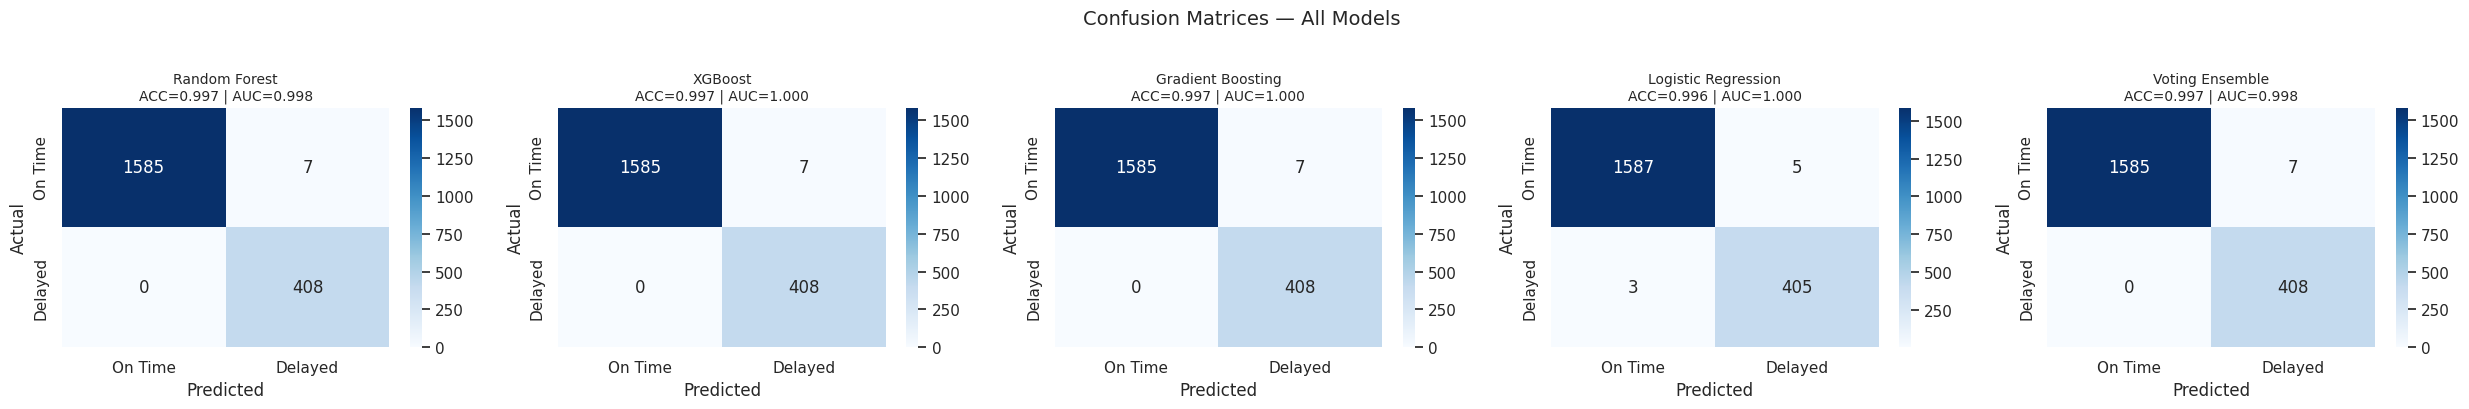


Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Precision
Model                                                                             
Random Forest          0.9965     0.9831  1.0000    0.9915   0.9981         0.9802
XGBoost                0.9965     0.9831  1.0000    0.9915   0.9996         0.9980
Gradient Boosting      0.9965     0.9831  1.0000    0.9915   0.9997         0.9988
Logistic Regression    0.9960     0.9878  0.9926    0.9902   0.9998         0.9990
Voting Ensemble        0.9965     0.9831  1.0000    0.9915   0.9983         0.9823

 Best Model: Logistic Regression  (ROC-AUC = 0.9998)


In [89]:
# CELL 16 — Evaluate All Models (Metrics + Confusion Matrices)

print("=" * 55)
print("  STEP 8: MODEL EVALUATION")
print("=" * 55)

results_list = []
n = len(trained_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    ap   = average_precision_score(y_test, y_proba)

    results_list.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc, 'Avg-Precision': ap
    })

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['On Time','Delayed'],
                yticklabels=['On Time','Delayed'])
    ax.set_title(f"{name}\nACC={acc:.3f} | AUC={auc:.3f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/07_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results_list).set_index('Model').round(4)
print("\nModel Comparison Table:")
print(results_df.to_string())

best_model_name = results_df['ROC-AUC'].idxmax()
print(f"\n Best Model: {best_model_name}"
      f"  (ROC-AUC = {results_df.loc[best_model_name,'ROC-AUC']:.4f})")

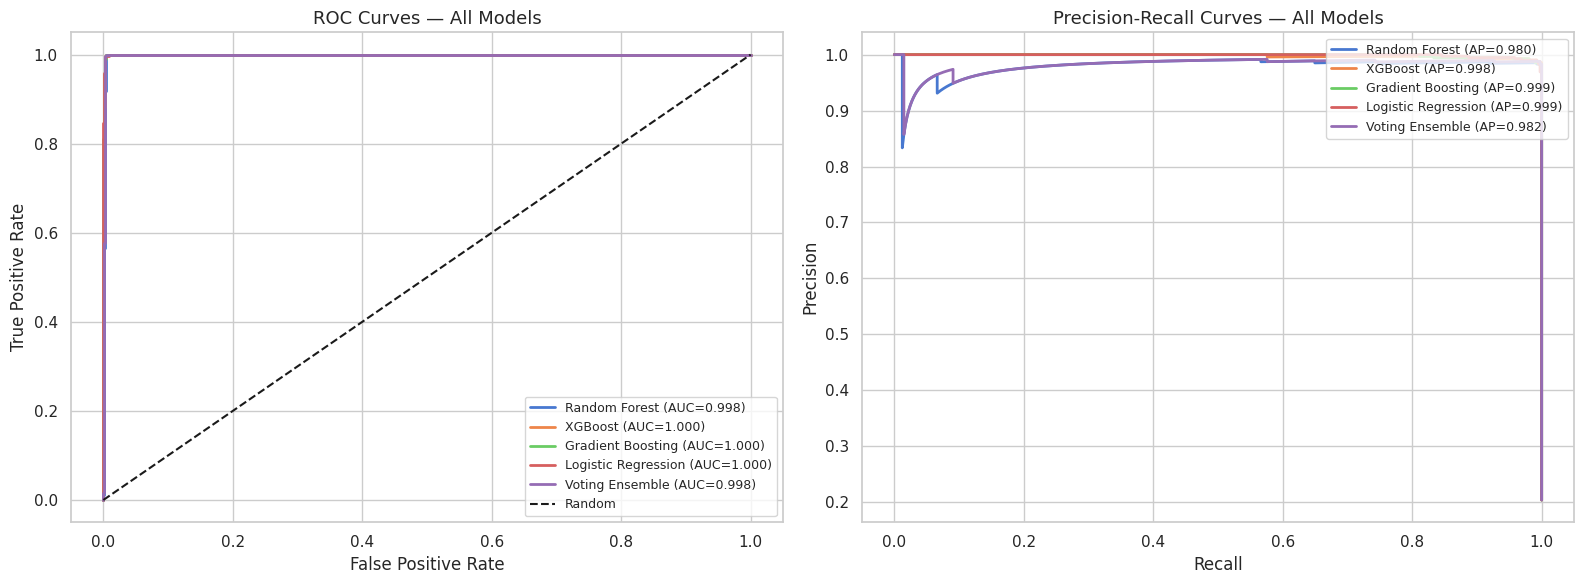

Plot saved: plots/08_roc_pr_curves.png


In [90]:
# CELL 17 — ROC Curves + Precision-Recall Curves

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
for name, model in trained_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curves — All Models", fontsize=13)
axes[0].legend(loc='lower right', fontsize=9)

# Precision-Recall Curves
for name, model in trained_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec_c, prec_c, lw=2, label=f"{name} (AP={ap:.3f})")

axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curves — All Models", fontsize=13)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("plots/08_roc_pr_curves.png", dpi=150)
plt.show()
print("Plot saved: plots/08_roc_pr_curves.png")

Feature Importance for: Logistic Regression


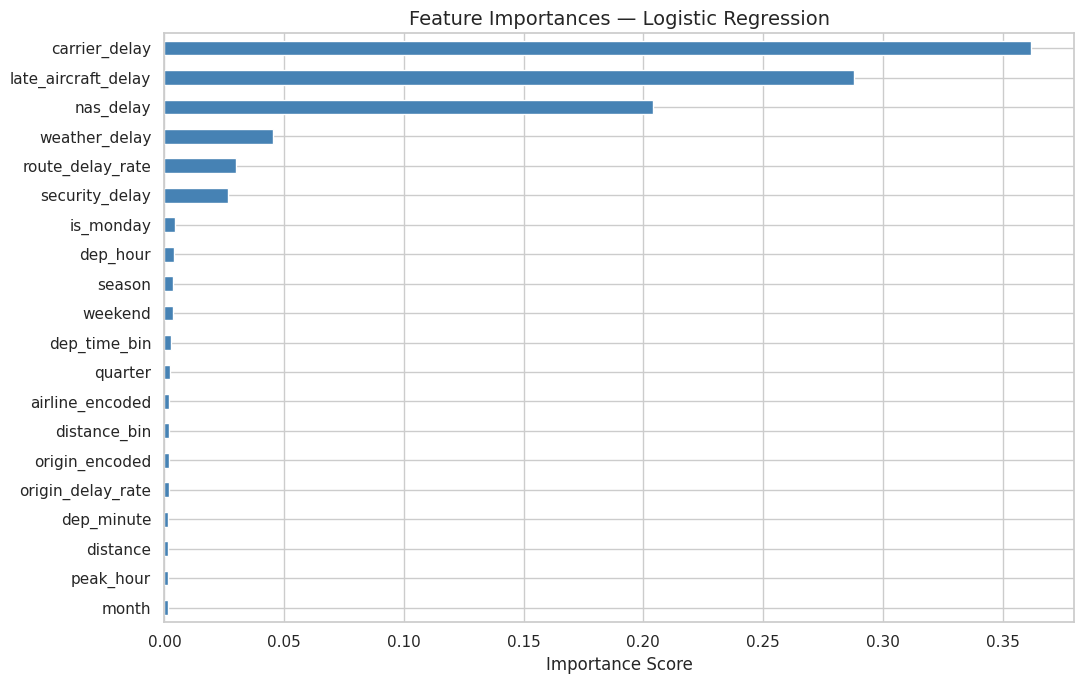


 Top 15 Most Important Features:
carrier_delay          0.361746
late_aircraft_delay    0.288087
nas_delay              0.204094
weather_delay          0.045501
route_delay_rate       0.029853
security_delay         0.026638
is_monday              0.004512
dep_hour               0.003876
season                 0.003560
weekend                0.003368
dep_time_bin           0.002531
quarter                0.002480
airline_encoded        0.001876
distance_bin           0.001867
origin_encoded         0.001778


In [91]:
# CELL 18 — Feature Importance (Best Model)

print(f"Feature Importance for: {best_model_name}")

best_model = trained_models[best_model_name]

# Use RF or XGB directly if ensemble
model_for_importance = best_model
if not hasattr(best_model, 'feature_importances_'):
    model_for_importance = trained_models.get('XGBoost', trained_models.get('Random Forest'))

if hasattr(model_for_importance, 'feature_importances_'):
    imp = pd.Series(model_for_importance.feature_importances_, index=FEATURE_COLS)
    imp_sorted = imp.sort_values(ascending=True).tail(20)

    plt.figure(figsize=(11, 7))
    imp_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f"Feature Importances — {best_model_name}", fontsize=14)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("plots/09_feature_importance.png", dpi=150)
    plt.show()

    print("\n Top 15 Most Important Features:")
    print(imp.sort_values(ascending=False).head(15).to_string())
else:
    print(" Feature importance not available for this model type.")

Running SHAP on: XGBoost (for best explainability)


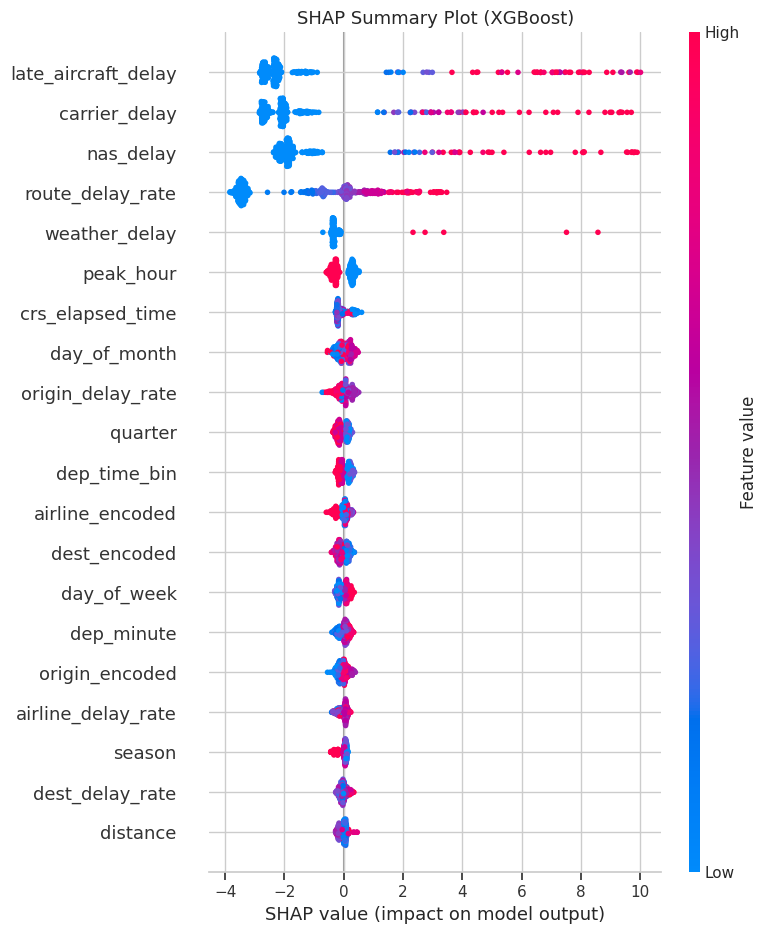

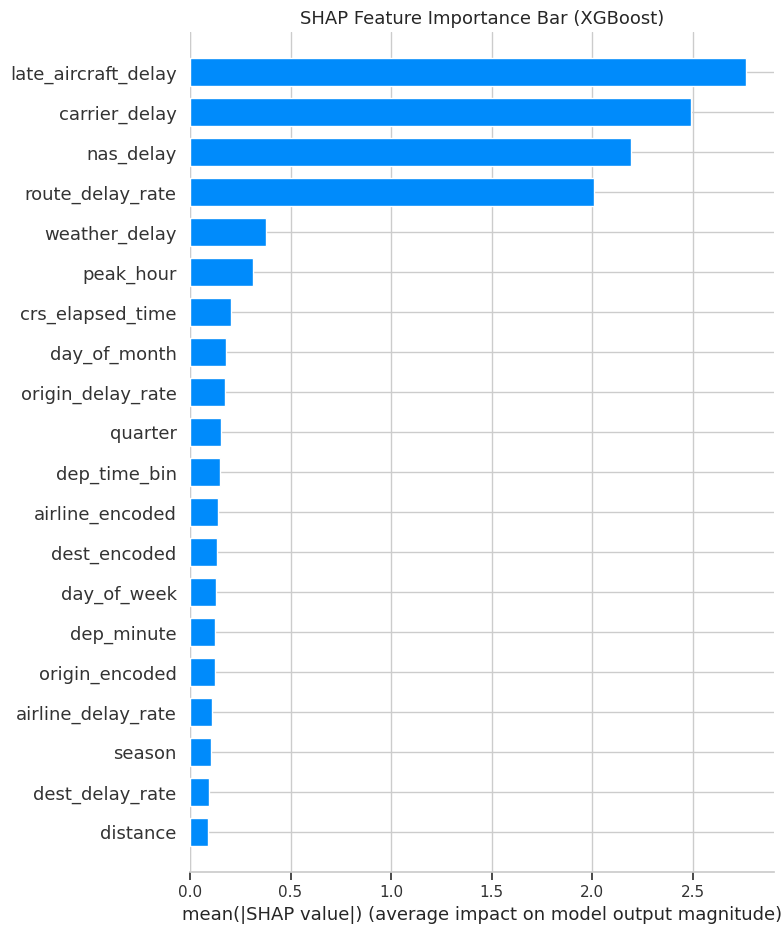

 SHAP plots saved!


In [92]:
# CELL 19 — SHAP Explainability (Why did the model predict this?)

import shap

print(f"Running SHAP on: XGBoost (for best explainability)")
xgb_model = trained_models['XGBoost']

sample_shap = X_test_scaled.iloc[:500]

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(sample_shap)

plt.figure()
shap.summary_plot(shap_vals, sample_shap,
                  feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Summary Plot (XGBoost)", fontsize=13)
plt.tight_layout()
plt.savefig("plots/10_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar plot (mean importance)
plt.figure()
shap.summary_plot(shap_vals, sample_shap,
                  feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
plt.title("SHAP Feature Importance Bar (XGBoost)", fontsize=13)
plt.tight_layout()
plt.savefig("plots/11_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP plots saved!")

In [93]:
# CELL 20 — Save All Models & Artifacts

joblib.dump(trained_models[best_model_name], "model_artifacts/best_model.pkl")
joblib.dump(scaler,                          "model_artifacts/scaler.pkl")
joblib.dump(encoders,                        "model_artifacts/encoders.pkl")
joblib.dump(FEATURE_COLS,                    "model_artifacts/feature_cols.pkl")
joblib.dump(trained_models,                  "model_artifacts/all_models.pkl")

print(" Saved artifacts:")
for f in os.listdir("model_artifacts"):
    size = os.path.getsize(f"model_artifacts/{f}") / 1024
    print(f"    {f}  ({size:.1f} KB)")

 Saved artifacts:
    feature_cols.pkl  (0.4 KB)
    all_models.pkl  (12727.6 KB)
    encoders.pkl  (4.3 KB)
    best_model.pkl  (1.7 KB)
    scaler.pkl  (1.9 KB)


In [94]:

print("=" * 55)
print("  RANDOM SAMPLE PREDICTIONS")
print("=" * 55)

np.random.seed(99)
indices = np.random.choice(len(X_test_scaled), 5, replace=False)

for i, idx in enumerate(indices, 1):
    sample = X_test_scaled.iloc[[idx]]
    actual = y_test.iloc[idx]
    print(f"\n  ── Sample #{i}  |  Actual: {'🔴 Delayed' if actual==1 else '🟢 On Time'}")
    for name, model in trained_models.items():
        pred  = model.predict(sample)[0]
        proba = model.predict_proba(sample)[0][1]
        tick  = "✓" if pred == actual else "✗"
        label = "Delayed" if pred == 1 else "On Time"
        print(f"    [{tick}] {name:22s} → {label:8s}  (confidence: {proba*100:.1f}%)")

  RANDOM SAMPLE PREDICTIONS

  ── Sample #1  |  Actual: 🔴 Delayed
    [✓] Random Forest          → Delayed   (confidence: 98.0%)
    [✓] XGBoost                → Delayed   (confidence: 100.0%)
    [✓] Gradient Boosting      → Delayed   (confidence: 100.0%)
    [✓] Logistic Regression    → Delayed   (confidence: 99.9%)
    [✓] Voting Ensemble        → Delayed   (confidence: 99.3%)

  ── Sample #2  |  Actual: 🔴 Delayed
    [✓] Random Forest          → Delayed   (confidence: 79.9%)
    [✓] XGBoost                → Delayed   (confidence: 99.9%)
    [✓] Gradient Boosting      → Delayed   (confidence: 100.0%)
    [✓] Logistic Regression    → Delayed   (confidence: 100.0%)
    [✓] Voting Ensemble        → Delayed   (confidence: 93.3%)

  ── Sample #3  |  Actual: 🟢 On Time
    [✓] Random Forest          → On Time   (confidence: 3.8%)
    [✓] XGBoost                → On Time   (confidence: 0.0%)
    [✓] Gradient Boosting      → On Time   (confidence: 0.0%)
    [✓] Logistic Regression    → On Ti

In [95]:
# CELL 22 — Predict Delay for Any Custom Flight

def predict_single_flight(airline, origin, dest, dep_hour,
                           day_of_week, month, distance=800.0,
                           crs_elapsed_time=120.0,
                           carrier_delay=0.0, weather_delay=0.0):
    """
    Predict delay probability for one flight.
    airline       : carrier code e.g. 'WN', 'AA', 'DL'
    origin        : origin airport e.g. 'ATL'
    dest          : destination airport e.g. 'ORD'
    dep_hour      : departure hour (0-23)
    day_of_week   : 1=Mon … 7=Sun
    month         : 1-12
    distance      : route distance in miles
    """
    season_map = {12:1,1:1,2:1, 3:2,4:2,5:2, 6:3,7:3,8:3, 9:4,10:4,11:4}

    def safe_enc(key, val):
        if key in encoders:
            try:
                return encoders[key].transform([str(val)])[0]
            except ValueError:
                return 0
        return 0

    # Historical rates
    def get_rate(col, val):
        if col in df.columns:
            return df.groupby(col)['Is_Delayed'].mean().get(val, 0.30)
        return 0.30

    carrier_col_local = 'op_unique_carrier' if 'op_unique_carrier' in df.columns else 'op_carrier'
    route_key = f"{origin}-{dest}"
    route_rate = df.groupby('route')['Is_Delayed'].mean().get(route_key, 0.30) \
                 if 'route' in df.columns else 0.30

    sample = {
        'airline_encoded':     safe_enc('airline_encoded', airline),
        'origin_encoded':      safe_enc('origin_encoded',  origin),
        'dest_encoded':        safe_enc('dest_encoded',    dest),
        'dep_hour':            dep_hour,
        'dep_minute':          0,
        'dep_time_bin':        min(dep_hour // 4, 5),
        'day_of_week':         day_of_week,
        'day_of_month':        15,
        'month':               month,
        'quarter':             (month - 1) // 3 + 1,
        'season':              season_map.get(month, 1),
        'peak_hour':           int((6<=dep_hour<=9) or (17<=dep_hour<=21)),
        'red_eye':             int(dep_hour<=5 or dep_hour>=22),
        'weekend':             int(day_of_week in [6, 7, 0]),
        'is_monday':           int(day_of_week == 1),
        'is_friday':           int(day_of_week == 5),
        'distance':            distance,
        'distance_bin':        min(int(distance // 500), 3),
        'crs_elapsed_time':    crs_elapsed_time,
        'carrier_delay':       carrier_delay,
        'weather_delay':       weather_delay,
        'nas_delay':           0,
        'security_delay':      0,
        'late_aircraft_delay': 0,
        'airline_delay_rate':  get_rate(carrier_col_local, airline),
        'origin_delay_rate':   get_rate('origin', origin),
        'dest_delay_rate':     get_rate('dest', dest),
        'route_delay_rate':    route_rate,
        'fl_num_freq':         1,
    }

    row = pd.DataFrame([{c: sample.get(c, 0) for c in FEATURE_COLS}])
    row_scaled = scaler.transform(row)

    pred  = trained_models[best_model_name].predict(row_scaled)[0]
    proba = trained_models[best_model_name].predict_proba(row_scaled)[0][1]

    risk = "🟢 LOW" if proba < 0.35 else ("🟡 MEDIUM" if proba < 0.60 else "🔴 HIGH")

    print("=" * 45)
    print(f"  ✈️   {origin} → {dest}  |  {dep_hour:02d}:00")
    print(f"  Airline     : {airline}")
    print(f"  Month       : {month}  |  Day: {day_of_week}")
    print(f"  Distance    : {distance:.0f} mi")
    print("─" * 45)
    print(f"  Prediction  : {'🔴 DELAYED' if pred==1 else '🟢 ON TIME'}")
    print(f"  Delay Prob  : {proba*100:.1f}%")
    print(f"  Risk Level  : {risk}")
    print("=" * 45)


# ── Test with real flights from your dataset ──
predict_single_flight('WN', 'OMA', 'ATL', dep_hour=17,
                      day_of_week=5, month=7, distance=1099)

predict_single_flight('AA', 'CLT', 'LAX', dep_hour=8,
                      day_of_week=2, month=3, distance=2125)

predict_single_flight('9E', 'CHA', 'ATL', dep_hour=6,
                      day_of_week=1, month=12, distance=106)

  ✈️   OMA → ATL  |  17:00
  Airline     : WN
  Month       : 7  |  Day: 5
  Distance    : 1099 mi
─────────────────────────────────────────────
  Prediction  : 🟢 ON TIME
  Delay Prob  : 34.2%
  Risk Level  : 🟢 LOW
  ✈️   CLT → LAX  |  08:00
  Airline     : AA
  Month       : 3  |  Day: 2
  Distance    : 2125 mi
─────────────────────────────────────────────
  Prediction  : 🟢 ON TIME
  Delay Prob  : 0.9%
  Risk Level  : 🟢 LOW
  ✈️   CHA → ATL  |  06:00
  Airline     : 9E
  Month       : 12  |  Day: 1
  Distance    : 106 mi
─────────────────────────────────────────────
  Prediction  : 🟢 ON TIME
  Delay Prob  : 0.6%
  Risk Level  : 🟢 LOW


In [96]:
# CELL 23 — Final Summary

print("=" * 55)
print("   PROJECT COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"\n  Dataset size    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Features used   : {len(FEATURE_COLS)}")
print(f"  Overall delay % : {df['Is_Delayed'].mean()*100:.1f}%")
print(f"\n  Models trained  : {list(trained_models.keys())}")
print(f"\n Final Leaderboard:")
print(results_df.sort_values('ROC-AUC', ascending=False).to_string())
print(f"\n Best Model    : {best_model_name}")
print(f"   ROC-AUC      : {results_df.loc[best_model_name,'ROC-AUC']:.4f}")
print(f"   F1-Score     : {results_df.loc[best_model_name,'F1-Score']:.4f}")
print(f"\n Saved to      : model_artifacts/")
print(f" Plots saved   : plots/")
print("\n" + "=" * 55)

   PROJECT COMPLETE — FINAL SUMMARY

  Dataset size    : 10,000 rows × 52 columns
  Features used   : 29
  Overall delay % : 20.4%

  Models trained  : ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Logistic Regression', 'Voting Ensemble']

 Final Leaderboard:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Precision
Model                                                                             
Logistic Regression    0.9960     0.9878  0.9926    0.9902   0.9998         0.9990
Gradient Boosting      0.9965     0.9831  1.0000    0.9915   0.9997         0.9988
XGBoost                0.9965     0.9831  1.0000    0.9915   0.9996         0.9980
Voting Ensemble        0.9965     0.9831  1.0000    0.9915   0.9983         0.9823
Random Forest          0.9965     0.9831  1.0000    0.9915   0.9981         0.9802

 Best Model    : Logistic Regression
   ROC-AUC      : 0.9998
   F1-Score     : 0.9902

 Saved to      : model_artifacts/
 Plots saved   : plots/

